In [1]:
from urllib.parse import urlencode, unquote, quote_plus
from urllib.request import urlopen
import urllib
from datetime import datetime, timedelta
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xmltodict
import requests
import json

In [2]:
def mk_ttl_col(df):                        # 첫열(월별 기간) 인덱스화 및 대여 총계 컬럼 생성 함수
    df.set_index('월', inplace=True)
    df['Total'] = df.sum(axis=1)
    return df

def t(get_color = 'y'):                   # 작업환경이 어두운 Theme이라 텍스트 밝은색으로 만드는 함수
    plt.tick_params(color = get_color)
    plt.xticks(color = get_color)
    plt.yticks(color = get_color)

def mk_subplot(df, title_name, index):    # subplot 만드는 함수
    fp_ttl = fm.FontProperties(fname="malgun.ttf", size=16)    # 타이틀 폰트 및 크기 조정
    fp_lbl = fm.FontProperties(fname="malgun.ttf", size=12)    # 라벨 폰트 및 크기 조정

    plt.subplot(5, 2, index)              # 서브차트 10개
    df['Total'].plot(kind='bar')          # 바 차트 생성
    plt.title(title_name , c='w', fontproperties=fp_ttl)
    plt.xlabel('기간', c='w', fontproperties=fp_lbl)
    plt.ylabel('대여 도서', c='w', fontproperties=fp_lbl)
    t()
    
def mk_bar_single_chart(df, title_name):
    plt.bar(df['Total'], label=title_name)          # 바 차트 생성
    

In [3]:
def compare_sub(a,b):
    if a > b :
        c = a-b
        return c
    else :
        c = b-a
        return c

In [4]:
df_TS = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_기술과학-세대별대출분석.xlsx"))
df_lit = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_문학-세대별대출분석.xlsx"))
df_SS = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_사회과학-세대별대출분석.xlsx"))
df_ling = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_언어-세대별대출분석.xlsx"))
df_hist = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_역사-세대별대출분석.xlsx"))
df_art = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_예술-세대별대출분석.xlsx"))
df_NS = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_자연과학-세대별대출분석.xlsx"))
df_rel = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_종교-세대별대출분석.xlsx"))
df_phil = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_철학-세대별대출분석.xlsx"))
df_ttl = mk_ttl_col(pd.read_excel("./xlsx/이용자테마데이터_총류-세대별대출분석.xlsx"))
# 서브플롯 반복문으로 생성하기 위해 딕셔너리화
dict_df = {'기술과학':df_TS,'문학':df_lit,'사회과학':df_SS,'언어':df_ling,'역사':df_hist,
           '예술':df_art,'자연과학':df_NS,'종교':df_rel,'철학':df_phil,'총류':df_ttl}

In [5]:
df_merge = pd.concat([df_TS['Total'], df_lit['Total'], df_SS['Total'], df_ling['Total'],
                      df_hist['Total'], df_art['Total'], df_NS['Total'], df_rel['Total'],
                      df_phil['Total'], df_ttl['Total']], axis=1)
df_merge.columns = ['기술과학','문학','사회과학','언어','역사','예술','자연과학','종교','철학','총류']
df_merge['Total'] = df_merge.sum(axis=1)

In [6]:
merge_only = df_merge.drop(['기술과학', '문학', '사회과학', '언어', '역사',
                            '예술', '자연과학', '종교', '철학', '총류'], axis=1)
# display(merge_only.head(5))
# display(merge_only.tail(5))

In [7]:
my_api_key = 'tSMM06oOg%2FBMrPoKdXrNjH0PY5DEZdD6VL%2B3bL7EXugsZ8wxCQJWKkxHsOzWNFW0dZRgYgyI02Z7SSRiTD6UcA%3D%3D'

url = 'http://openapi.data.go.kr/openapi/service/rest/Covid19/getCovid19InfStateJson'

queryParams = '?' + \
'ServiceKey=' + '{}'.format(my_api_key) + \
'&pageNo=' + '1' + \
'&numOfRows=' + '999' + \
'&startCreateDt=20190101&endCreateDt=20210331'#.format(yseter,now_today)

In [8]:
result = requests.get(url + queryParams)
#print(result)


result = result.content
jsonString = json.dumps(xmltodict.parse(result),indent=4)
jsonString = jsonString.replace('resultCode','결과코드').replace('resultMsg','결과메세지').replace('numOfRows', '한 페이지 결과 수').replace('pageNo','페이지 수').replace('totalCount', '전체 결과 수').replace('seq','게시글번호(감염현황 고유값)').replace('stateDt', '기준일').replace('stateTime', '기준시간').replace('decideCnt', '누적 확진자 수').replace('clearCnt', '격리해제 수').replace('examCnt', '검사진행 수').replace('deathCnt', '누적 사망자 수').replace('careCnt', '치료중 환자 수').replace('resutlNegCnt', '결과 음성 수').replace('accExamCnt', '누적 검사 수').replace('accExamCompCnt', '누적 검사 완료 수').replace('accDefRate', '누적 확진률').replace('createDt', '등록일시분초').replace('updateDt', '수정일시분초')

js = json.loads(jsonString)
#print(js)
js_check_count = js["response"]['body']['items']['item'][0]['검사진행 수']
js = js["response"]['body']['items']['item']
all_data = pd.DataFrame(js)

In [9]:
select_data = all_data[['기준일','누적 사망자 수','누적 검사 수', '누적 확진자 수']]
# nan 값을 0으로 치환
select_data = select_data.fillna(0)
select_data.sort_values(by = '기준일', inplace = True, ascending = True)
select_data = select_data.reset_index(drop = True)
# select_data

In [10]:
select_data['누적 확진자 수'] = pd.to_numeric(select_data['누적 확진자 수'])
select_data['기준일'] = pd.to_datetime(select_data['기준일'])

# groupby를 사용하여 집계를 할 때 기준 연산을 설정.. 
f = {'누적 확진자 수':'min','누적 검사 수':'max','누적 사망자 수':'max'}
# 기준일을 기준으로 집계
data1 = select_data.groupby('기준일').agg(f)
# 기준일을 기준으로 정렬
data1.sort_values(by = '기준일', inplace=True, ascending = True)
pdata = data1.reset_index(drop = False)
pdata.columns = ['기준일', '누적 확진자 수', '누적 검사 수', '누적 사망자 수']
# pdata.head(5)

In [11]:
daily_crn_cnt = []
daily_check_cnt = []
for row in range(0,len(pdata['누적 확진자 수'])-1):
    daily_crn_cnt.append(compare_sub(int(pdata.loc[row+1][1]), int(pdata.loc[row][1])))
    # print(pdata['기준일'][row],',',int(pdata.loc[row+1][1]) ,'-', int(pdata.loc[row][1]) ,'=', compare_sub(int(pdata.loc[row+1][1]), int(pdata.loc[row][1])))
    daily_check_cnt.append(compare_sub(int(pdata.loc[row+1][2]),int(pdata.loc[row][2])))
    # print(pdata['기준일'][row],',',int(pdata.loc[row+1][2]),'-',int(pdata.loc[row][2]), '=', compare_sub(int(pdata.loc[row+1][2]),int(pdata.loc[row][2])))
pdata = pdata.drop(1)
pdata['일일 확진자 수'] = daily_crn_cnt
pdata['일일 검사 수'] = daily_check_cnt
pdata['일일 검사 수'] = pd.to_numeric(pdata["일일 검사 수"])
pdata['누적 사망자 수'] = pd.to_numeric(pdata['누적 사망자 수'])
# pdata.head(5)

In [12]:
npdata = pdata
npdata['all_test_num'] = 1
npdata.set_index(npdata['기준일'], inplace=True)
npdata = npdata.drop('기준일', 1)
npdata.index.strftime("%Y-%m")

Index(['2020-01', '2020-02', '2020-02', '2020-02', '2020-02', '2020-02',
       '2020-02', '2020-02', '2020-02', '2020-02',
       ...
       '2021-03', '2021-03', '2021-03', '2021-03', '2021-03', '2021-03',
       '2021-03', '2021-03', '2021-03', '2021-03'],
      dtype='object', name='기준일', length=425)

In [13]:
monthly_df = npdata.resample('M').sum()
monthly_df.rename(columns={"일일 확진자 수":'월별 확진자 수', '일일 검사 수':'월별 검사 수'}
                  , inplace=True)
monthly_df.set_index(monthly_df.index.strftime("%Y-%m"), inplace=True)
monthly_df.index.name = '기준월'
monthly_df.drop(['누적 확진자 수','누적 사망자 수','월별 검사 수','all_test_num'], axis=1, inplace=True)

In [14]:
covid_monthly_df = pd.DataFrame(data='0', columns=monthly_df.columns, 
                       index=pd.date_range('2019-01', '2020-01', freq='m').strftime("%Y-%m"))
covid_monthly_df = covid_monthly_df.append(monthly_df)
covid_monthly_df = covid_monthly_df.astype('int64')
# covid_monthly_df.tail(5)

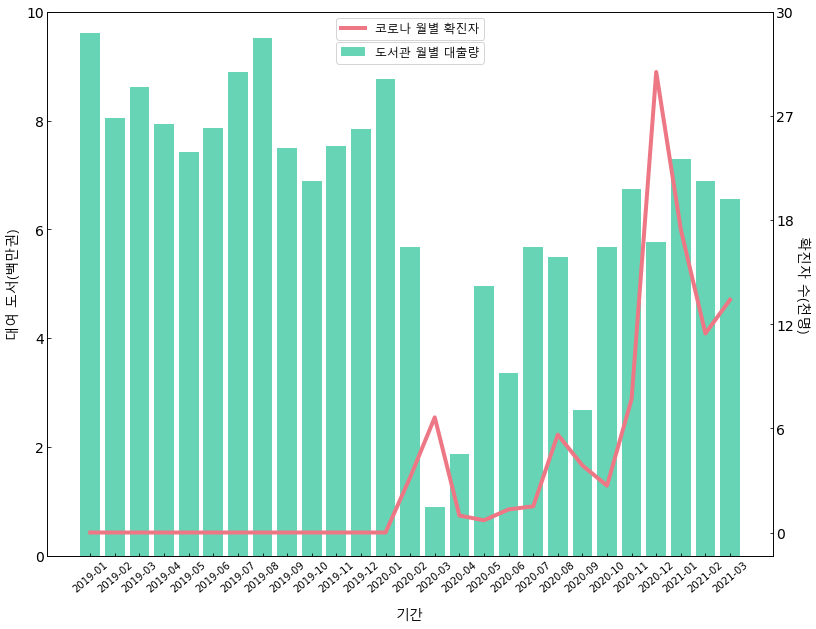

In [57]:
## your font directory 
font_path = "malgun.ttf"
## font_name 
font_name = fm.FontProperties(fname=font_path).get_name()

fp_lbl = fm.FontProperties(fname="malgun.ttf", size=14)

# 3. 그래프 그리기
plt.rcParams["figure.figsize"] = (13,10)
fig, ax1 = plt.subplots()

ax1.set_facecolor('none')
ax1.set_ylim(0, 10000000)
ax1.bar(np.arange(len(merge_only)),merge_only['Total'], color='#67D5B5', label='도서관 월별 대출량')
ax1.set_xlabel('기간', c='k', labelpad=15, fontproperties=fp_lbl)
ax1.set_ylabel('대여 도서(백만권)', c='k', labelpad=5, fontproperties=fp_lbl)
plt.xticks(color = 'k', rotation=40)
plt.yticks(np.arange(0, 10000001, 2000000), 
           ('0','2','4','6','8','10'),
           color = 'k', size=14)
ax1.tick_params(color = 'k')
ax1.tick_params(axis='both', direction='in')
ax1.legend(loc=(0.398, 0.905), prop={'family':font_name, 'size':12})

ax2 = ax1.twinx()
ax2.plot(covid_monthly_df, color='#EE7785', linewidth=4, label='코로나 월별 확진자')
ax2.set_ylabel('확진자 수(천명)', c='k', labelpad=15, rotation=270, fontproperties=fp_lbl)
# ax2.set_ylim(1000, 30000)
plt.yticks(np.arange(0, 30001, 6000), 
           ('0','6','12','18','27','30'),
           color = 'k', size=14)
ax2.tick_params(color = 'k')
ax2.tick_params(axis='y', direction='in')
ax2.legend(loc=9,prop={'family':font_name, 'size':12})

plt.savefig('theme data combine with COVID-19 API(배경투명버전).jpg', transparent = True)
plt.show()